# 08 - DTW with a Sakoe-Chiba band

*Source*: https://link.springer.com/article/10.1007/s10115-022-01725-1?utm_source=researchgate.net&utm_medium=article

*Code*: Claude Opus 5

The DTW of notebook 01 fills the *whole* `n x m` cost matrix, although the optimal path
almost always stays close to the diagonal: matching sample 10 of one series to sample 250
of the other is never a sensible alignment. The Sakoe-Chiba band makes this explicit. It
only computes cells within a fixed distance `w` of the diagonal, `|i - j| <= w`, and treats
everything outside as unreachable.

**What we gain.** Only `O(n * w)` cells instead of `O(n * m)`, so the run time drops
roughly by the factor `2w / m`. As a side effect the band also *regularises* the
alignment: it forbids the pathological warpings where a long stretch of one series is
matched to a single sample of the other.

**What we risk.** The band is a hard constraint. If two series are shifted against each
other by more than `w` samples, the true alignment lies outside the band and DTW returns a
larger distance than the unconstrained version. The band width must therefore be chosen
from the time shifts one *expects* between similar series - the second half of the
notebook shows which variants are affected by which width.

Everything runs on the **raw** synthetic dataset, without the z-normalisation, so the distances are directly comparable with notebook 01.

In [10]:
import sys
import time
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dtaidistance import dtw

from data.synthetic import generate_dataset
from utils import plotting
from utils.distances import dtw_cost_matrix, dtw_path

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## The band

For two series of equal length the band is simply `|i - j| <= w`. Our `resampled` variant
is 30 % longer than the reference, though, and for such a pair the identity line `i = j`
never reaches the corner `(n, m)`. We therefore centre the band on the actual diagonal of
the `n x m` matrix, `j = i * (m - 1) / (n - 1)`, and allow `w` samples on either side of
it. For `n = m` this reduces to the textbook definition.

In [11]:
def sakoe_chiba_band(n: int, m: int, window: int) -> list[tuple[int, int]]:
    """Allowed column range ``(j_lo, j_hi)`` for each row of an ``n x m`` DP matrix.

    Indices are 1-based matrix indices (row/column 0 are the padding border), ranges
    are inclusive.  The band is centred on the diagonal of the matrix, so for series of
    unequal length it follows the stretched diagonal instead of the line ``i = j``.
    """
    bounds = []
    for i in range(1, n + 1):
        center = round((i - 1) * (m - 1) / (n - 1)) + 1
        bounds.append((max(1, center - window), min(m, center + window)))
    return bounds


def dtw_cost_matrix_band(x: np.ndarray, y: np.ndarray, window: int) -> np.ndarray:
    """Accumulated DTW cost matrix restricted to a Sakoe-Chiba band of half-width ``window``.

    Same recursion and same ``|x_i - y_j|`` local cost as ``utils.distances.dtw_cost_matrix``;
    cells outside the band keep the value ``inf`` and are never visited.
    """
    n, m = len(x), len(y)
    d = np.abs(x[:, None] - y[None, :])

    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i, (j_lo, j_hi) in enumerate(sakoe_chiba_band(n, m, window), start=1):
        for j in range(j_lo, j_hi + 1):
            D[i, j] = d[i - 1, j - 1] + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D


def band_cells(n: int, m: int, window: int) -> int:
    """Number of DP cells inside the band (= number of inner-loop iterations)."""
    return sum(j_hi - j_lo + 1 for j_lo, j_hi in sakoe_chiba_band(n, m, window))

In [12]:
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

# Sanity check 1: a band wide enough to cover the whole matrix reproduces the full DTW.
D_full = dtw_cost_matrix(reference, dataset["resampled"])
D_wide = dtw_cost_matrix_band(reference, dataset["resampled"], window=len(dataset["resampled"]))
print(f"full DTW           : {D_full[-1, -1]:.6f}")
print(f"band, w = m        : {D_wide[-1, -1]:.6f}")

# Sanity check 2: same band as dtaidistance on an equal-length pair.  dtaidistance
# uses the squared local cost and defines `window=w` as `|i - j| < w`, hence `w + 1`.
w = 10
x, y = reference, dataset["noisy"]
d_sq = (x[:, None] - y[None, :]) ** 2
D_sq = np.full((len(x) + 1, len(y) + 1), np.inf)
D_sq[0, 0] = 0.0
for i, (j_lo, j_hi) in enumerate(sakoe_chiba_band(len(x), len(y), w), start=1):
    for j in range(j_lo, j_hi + 1):
        D_sq[i, j] = d_sq[i - 1, j - 1] + min(D_sq[i - 1, j], D_sq[i, j - 1], D_sq[i - 1, j - 1])
print(f"band, squared cost : {np.sqrt(D_sq[-1, -1]):.6f}")
print(f"dtaidistance       : {dtw.distance(x, y, window=w + 1):.6f}")

full DTW           : 23.309964
band, w = m        : 23.309964
band, squared cost : 8.594767
dtaidistance       : 8.594767


## What the band looks like

`reference` vs. `resampled`, once with the full matrix and once with a band of `w = 30`.
White cells were never computed. The optimal path of the full version already lies inside
the band, so both versions find the same alignment and the same distance.

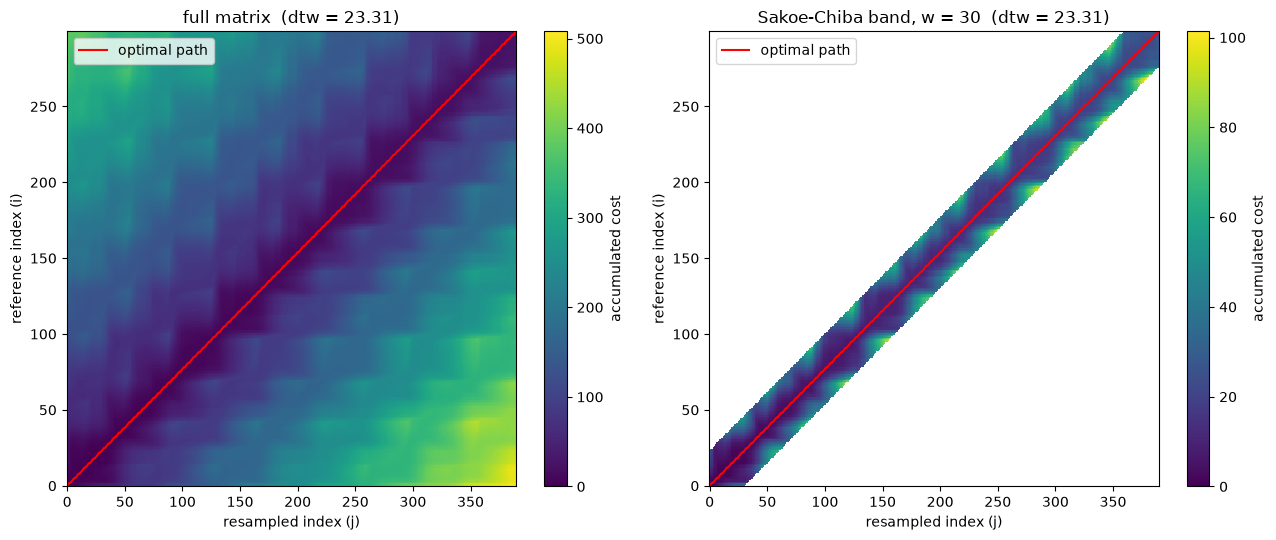

In [13]:
WINDOW = 30  # 10 % of the reference length, the classic Sakoe-Chiba default

y = dataset["resampled"]
D_band = dtw_cost_matrix_band(reference, y, WINDOW)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, D, title in ((axes[0], D_full, "full matrix"),
                     (axes[1], D_band, f"Sakoe-Chiba band, w = {WINDOW}")):
    cost = D[1:, 1:]
    plotting.plot_cost_matrix(
        np.where(np.isfinite(cost), cost, np.nan),  # NaN -> white, i.e. "not computed"
        path=dtw_path(D),
        title=f"{title}  (dtw = {D[-1, -1]:.2f})",
        xlabel="resampled index (j)",
        ylabel="reference index (i)",
        ax=ax,
    )
fig.tight_layout()
plt.show()

## Computing time

Every variant is compared with the reference for several band widths; `full` is the
unconstrained DTW of notebook 01. Times are the best of `REPEATS` runs. The loop also
records the resulting distance, which the next section uses.

In [14]:
REPEATS = 5
WINDOWS = [5, 10, 20, 30, 60, 120]


def timed(func, *args) -> tuple[float, np.ndarray]:
    """Result of ``func(*args)`` and the wall-clock seconds of the fastest of ``REPEATS`` calls."""
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        result = func(*args)
        times.append(time.perf_counter() - t0)
    return min(times), result


rows = []
for window in WINDOWS + ["full"]:
    for name in variants:
        y = dataset[name]
        if window == "full":
            seconds, D = timed(dtw_cost_matrix, reference, y)
            cells = len(reference) * len(y)
        else:
            seconds, D = timed(dtw_cost_matrix_band, reference, y, window)
            cells = band_cells(len(reference), len(y), window)
        rows.append({"window": window, "variant": name, "cells": cells,
                     "time [s]": seconds, "dtw": float(D[-1, -1])})

results = pd.DataFrame(rows)

In [15]:
# Cells and seconds summed over all six variants.
timing = results.groupby("window", sort=False)[["cells", "time [s]"]].sum()
timing["cells [%]"] = 100 * timing["cells"] / timing.loc["full", "cells"]
timing["speedup"] = timing.loc["full", "time [s]"] / timing["time [s]"]
timing

,cells,time [s],cells [%],speedup
window,,,,
5,19626,0.021,3.461,21.506
10,37164,0.031,6.554,14.679
20,71374,0.060,12.588,7.580
30,104430,0.095,18.418,4.833
60,196676,0.162,34.687,2.812
120,350012,0.308,61.731,1.483
full,567000,0.457,100.000,1.000


## What the band costs in accuracy

The same runs, now showing the distance. A banded DTW can never be *smaller* than the
full one (it optimises over fewer paths), so every column converges from above towards
`full`. How wide the band has to be before a variant reaches its unconstrained value
tells us how far its optimal path strays from the diagonal.

In [16]:
by_window = results.pivot(index="variant", columns="window", values="dtw").loc[variants]
by_window

window,5,10,20,30,60,120,full
variant,,,,,,,
amplitude_scaled,295.418,279.856,273.333,273.333,273.333,273.333,273.333
resampled,23.310,23.310,23.310,23.310,23.310,23.310,23.310
noisy,122.133,122.133,122.133,122.133,122.133,122.133,122.133
phase_shifted,270.295,161.459,83.383,83.347,83.347,83.347,83.347
reversed,703.332,591.164,290.482,100.358,100.358,100.358,100.358
unrelated,560.131,511.471,415.330,377.288,365.560,317.349,317.349


## Ranking

Distance from `reference` to every variant with the band of `w = 30`, next to the
unconstrained DTW of notebook 01, each with its rank (1 = most similar).

In [17]:
ranking = pd.DataFrame({
    "dtw_band": by_window[WINDOW],
    "dtw_full": by_window["full"],
}).sort_values("dtw_band")
ranking["rank_band"] = ranking["dtw_band"].rank().astype(int)
ranking["rank_full"] = ranking["dtw_full"].rank().astype(int)
ranking

,dtw_band,dtw_full,rank_band,rank_full
variant,,,,
resampled,23.310,23.310,1,1
phase_shifted,83.347,83.347,2,2
reversed,100.358,100.358,3,3
noisy,122.133,122.133,4,4
amplitude_scaled,273.333,273.333,5,5
unrelated,377.288,317.349,6,6


In [18]:
print(f"similarity to reference, Sakoe-Chiba band w = {WINDOW} (most similar first)")
print()
for rank, (name, row) in enumerate(ranking.iterrows(), start=1):
    print(f"{rank}. {name:<17} dtw_band = {row['dtw_band']:>8.3f}   (full: {row['dtw_full']:>8.3f})")

similarity to reference, Sakoe-Chiba band w = 30 (most similar first)

1. resampled         dtw_band =   23.310   (full:   23.310)
2. phase_shifted     dtw_band =   83.347   (full:   83.347)
3. reversed          dtw_band =  100.358   (full:  100.358)
4. noisy             dtw_band =  122.133   (full:  122.133)
5. amplitude_scaled  dtw_band =  273.333   (full:  273.333)
6. unrelated         dtw_band =  377.288   (full:  317.349)


## Conclusion

- **Speed.** Run time follows the number of DP cells: `w = 30` visits 18 % of the full
  matrix and runs 4-5x faster, `w = 5` visits 3.5 % and runs 15-30x faster. The exact
  factors fluctuate from run to run (a pure-Python loop timed on a busy machine), the
  `cells` column is the stable measure. On 300 samples this saves a fraction of a second;
  on the machine recordings of notebook 06 it is the difference between seconds and none.
- **Ranking.** With `w = 30` the order is exactly that of notebook 01:
  `resampled` < `phase_shifted` < `reversed` < `noisy` < `amplitude_scaled` < `unrelated`.
  Five of six distances are identical to the full DTW, because their optimal paths never
  leave a 30-sample corridor. Only `unrelated` grows (377 instead of 317): its full-matrix
  alignment matches long stretches of the step signal to single samples of the
  reference - exactly the warping the band is meant to forbid.
- **Choosing `w`.** The distance-vs-width table shows the required band directly:
  `noisy` and `resampled` are converged at `w = 5`, `phase_shifted` at `w = 20`
  (the 40-sample shift is 10 samples short of a full period of the 1 Hz component, so a
  shift of -10 aligns it), `reversed` needs `w = 30`. Too narrow a band turns a similar
  series into a dissimilar one: at `w = 10`, `phase_shifted` (161) would rank behind
  `noisy` (122).
- The band does not fix what notebook 07 fixed: `amplitude_scaled` still pays the factor
  of 2 on every sample. Sakoe-Chiba is a constraint on *time*, z-normalisation one on
  *amplitude*; the two are complementary.
- **IMPORTANT:** Accoring to the source paper, an unconstrained EDR works better than a SC-constrained EDR 